In [3]:
from sage.all import *
import time

start = time.time()

R.<q> = PowerSeriesRing(QQ, default_prec=360)

E4 = eisenstein_series_qexp(4, 360, K=QQ)
Delta = delta_qexp(360)

j = E4^3 / Delta
print(j)

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print()

recip_j = 1 / j
print(invj)

print()
print("Elapsed:", time.time() - start)

1/13824000*q^-1 + 31/576000 + 1823/128000*q + 2099/1350*q^2 + 3201111/51200*q^3 + 183068/125*q^4 + 1666013203/69120*q^5 + 38447838/125*q^6 + 330792548681/102400*q^7 + 261387296/9*q^8 + 5882296721823/25600*q^9 + 8162396307/5*q^10 + 24368651916586549/2304000*q^11 + 1581151836816/25*q^12 + 4511120473887169/12800*q^13 + 6225055514992804/3375*q^14 + 186878394764121249/20480*q^15 + 1072630520148736/25*q^16 + 7396784480974375681/38400*q^17 + 41449337342465229/50*q^18 + 7027968414997654639/2048*q^19 + 1850097424305599512/135*q^20 + 211750977233257384041/4000*q^21 + 4956291074424234402/25*q^22 + 166184027665619711558897/230400*q^23 + 319258655115753644928/125*q^24 + 9028391431883148920989/1024*q^25 + 100290517624586891884189/3375*q^26 + 100263966038418287309265/1024*q^27 + 7895126636391197617568/25*q^28 + 1724796979330374990692786047/1728000*q^29 + 15473373207542412676164/5*q^30 + 4823470141695196115853513823/512000*q^31 + 19023828426318159760463872/675*q^32 + 132677013761667897891158691/1600*q

In [1]:
import pickle
from sage.all import *
import time

start = time.time()

R.<q> = PowerSeriesRing(QQ, default_prec=500)

E4 = eisenstein_series_qexp(4, 500, K=QQ)
Delta = delta_qexp(500)

j = E4^3 / Delta



recip_j = 1 / j



recip_j_list =[] 
for k in range(1, 451):
    recip_j_list.append([k,recip_j[k]])
    if k%50==0:
        print("recip_j",k)

with open('/Users/barrybrent/data2/run17april26no1.txt', 'wb') as wfile:
    pickle.dump(recip_j_list, wfile) #output snipped


h_list=[(0,1)]+recip_j_list 
j_list=[(0,1)] # in equation D, not the classical invariant
for n in range(1,401):
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r][1]
    j_n=n*h_list[n][1]-sm
    j_list.append((n,j_n))
    if n%50==0:
        print("j_list:",n)

    
with open('/Users/barrybrent/data2/run17april26no2.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) # ouput snipped

now=time.time()
print("elapsed seconds:",now-start)

recip_j 50
recip_j 100
recip_j 150
recip_j 200
recip_j 250
recip_j 300
recip_j 350
recip_j 400
recip_j 450
j_list: 50
j_list: 100
j_list: 150
j_list: 200
j_list: 250
j_list: 300
j_list: 350
j_list: 400
elapsed seconds: 0.4559049606323242


In [2]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time

start=time.time()
with open('/Users/barrybrent/data2/run17april26no2.txt', 'rb') as rfile:
    j_list = pickle.load(rfile)
    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(2, 351):
    now=time.time()
    print(n,(now-start)/60)
    deformed_j_list=j_list[1:n]#<<<<<<<<<<<<<<<<<<<<<<<< undeformed
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run17aprilr26no3.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run17april26no4.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run17april26no5.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped

2 0.00014609893163045247
3 0.0008152484893798828
4 0.0008355816205342611
5 0.0011325995127360025
6 0.0011657317479451498
7 0.0011997342109680176
8 0.001245296001434326
9 0.0013061324755350749
10 0.0013997793197631837
11 0.0015046993891398113
12 0.0016295472780863444
13 0.0017818490664164226
14 0.001950685183207194
15 0.0021254976590474447
16 0.002336931228637695
17 0.002563933531443278
18 0.002843332290649414
19 0.003187048435211182
20 0.003536065419514974
21 0.0039721330006917315
22 0.0044885675112406416
23 0.005039000511169433
24 0.005606965223948161
25 0.006399850050608317
26 0.007183349132537842
27 0.008121029535929362
28 0.009179913997650146
29 0.010405182838439941
30 0.011950298150380453
31 0.013643101851145426
32 0.015442697207132976
33 0.017723484834035238
34 0.02053724924723307
35 0.023763330777486165
36 0.02702006498972575
37 0.030806334813435872
38 0.035085785388946536
39 0.03994221289952596
40 0.04557332992553711
41 0.05205538272857666
42 0.059344998995463055
43 0.066678730

KeyboardInterrupt: 

MINIMUM MODULI


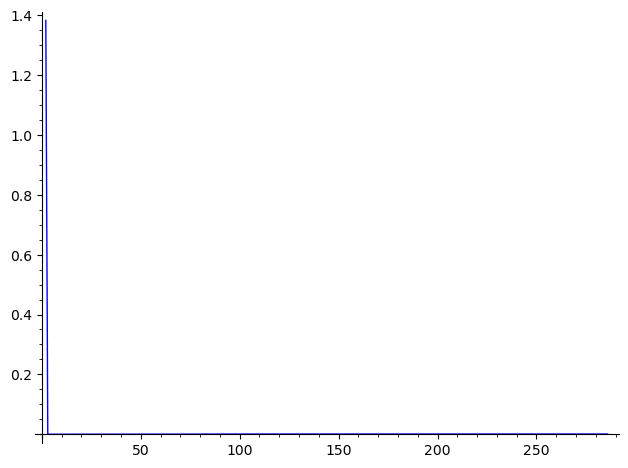

In [3]:
p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run17aprilr26no3.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run17april26no4.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run17april26no5.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped